In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
# Fix: Install scikit-learn and import GradientBoostingClassifier correctly
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
data=pd.read_excel("Gear Health.xlsx")
data = data.dropna(axis=1, how='all')

In [5]:
data = data.drop(
	columns=[
		'Color del Refrigerante','Glycerin (%)','Nitrito (ppm)','PUNTO DE EBULLICION (°C)',
		'Sólidos Totales Disueltos (ppm)','Turbidez (NTU)','pH','Added','Lube Drained','Live',
		'Lube Age','days','Observation Interval','Component Age', 'All Time Meter Reading',
		'Meter Reading','Observation Code','Observation Date', 'Observation Type','Connection Code',
		'Lubricant','Component Profile','Location','Component ID','SILICATOS (ppm)'
	],
	errors='ignore'
)

In [6]:
Salud = data[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)', 'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)','Sodio (ppm)']]

# se genera dataframe con las columnas que se van a utilizar Aluminio (ppm)   , Cobre (ppm), Cromo (ppm), Estaño (ppm), Hierro (ppm), Partículas Ferrosas (ppm), Plomo (ppm), Plata (ppm))
Desgaste = data[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Partículas Ferrosas (ppm)', 'Plomo (ppm)','Oxidación JOAP (Abs/cm)' ]]


# se genera dataframe con las columnas que se van a utilizar Agua (%), Dilución por combustible (%), Hollín JOAP (Abs/cm), Silicio (ppm)
Contaminacion = data[['Agua (%)', 'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)', 'Silicio (ppm)','Sodio (ppm)','Aluminio (ppm)']]


<Axes: >

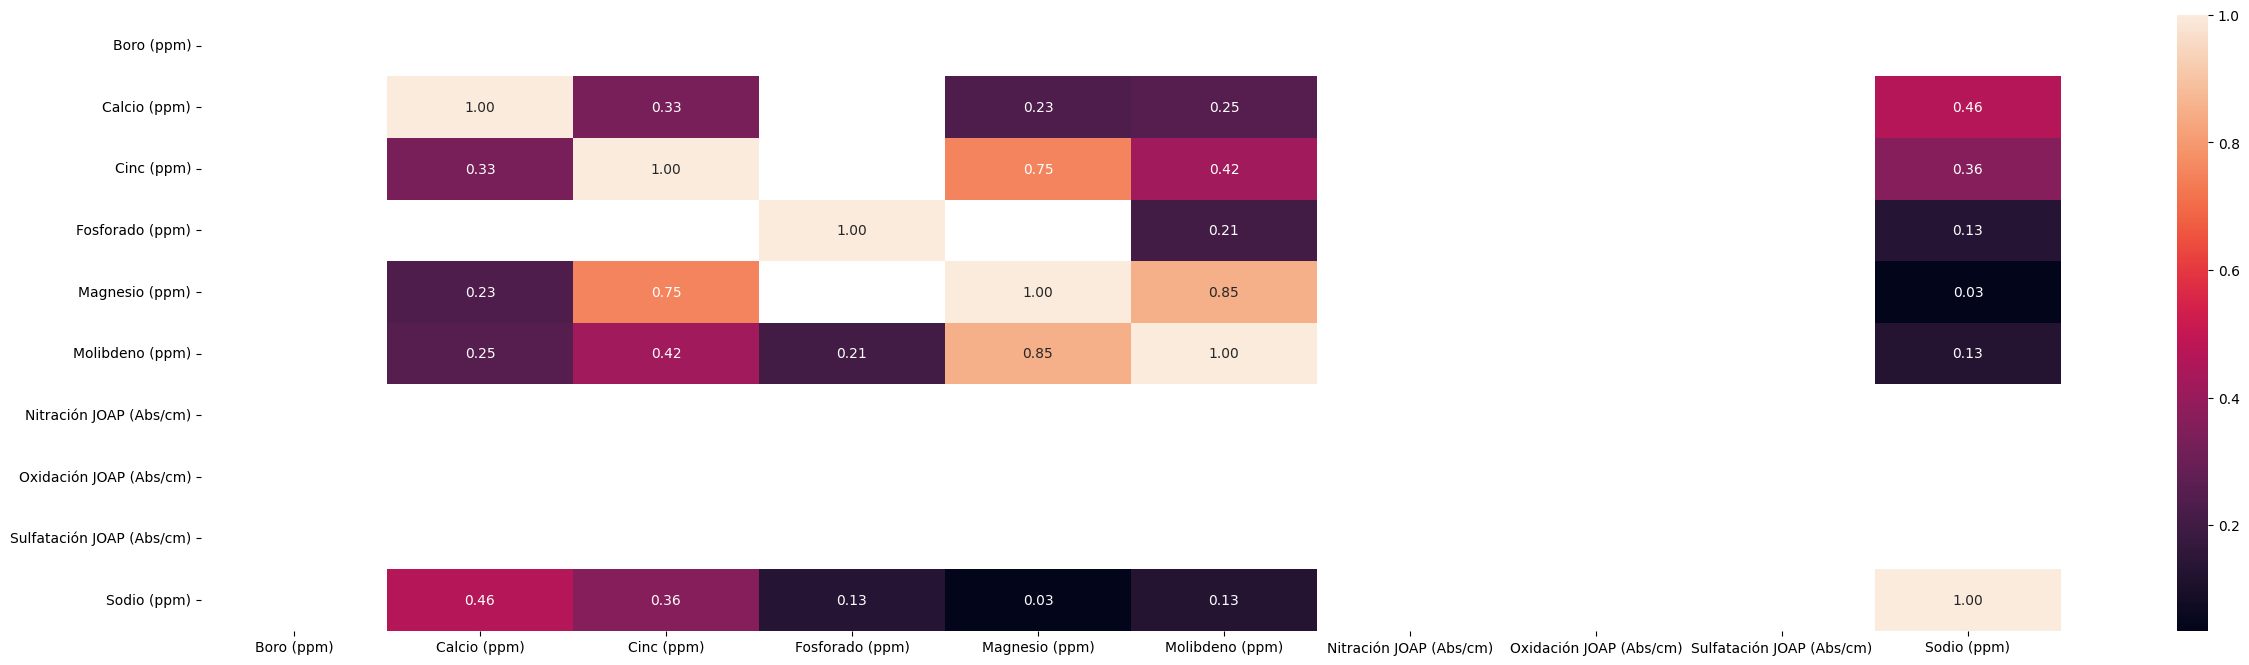

In [7]:
corr = Salud.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(30,8))
sns.heatmap(corr, annot=True, fmt=".2f")

<Axes: >

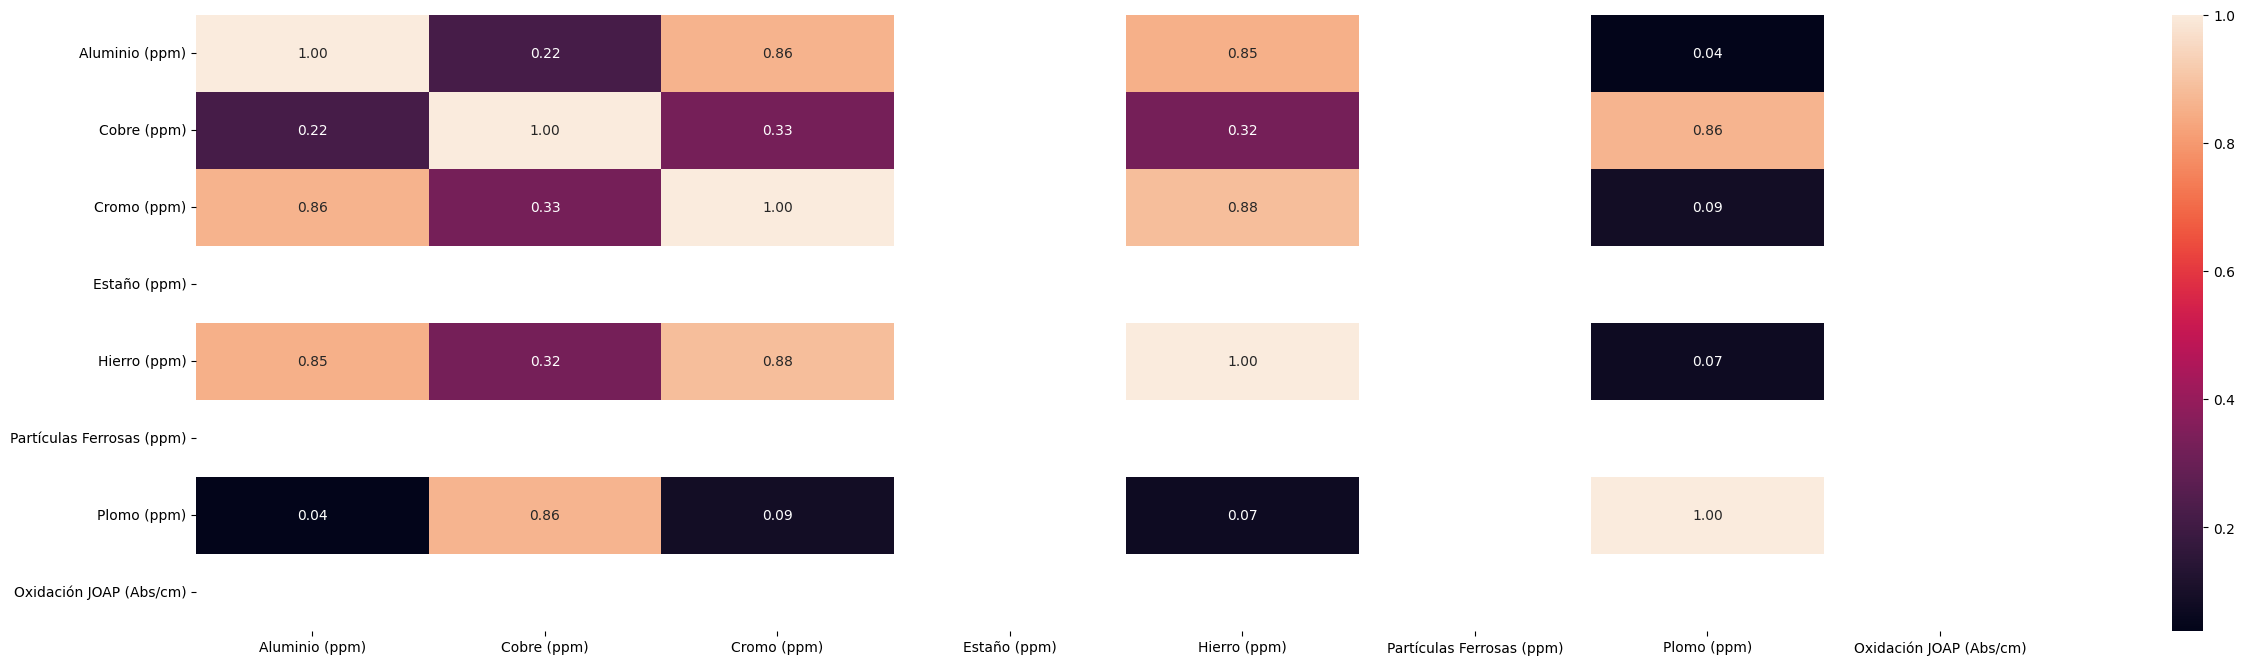

In [9]:

corr = Desgaste.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(30,8))
sns.heatmap(corr, annot=True, fmt=".2f")

<Axes: >

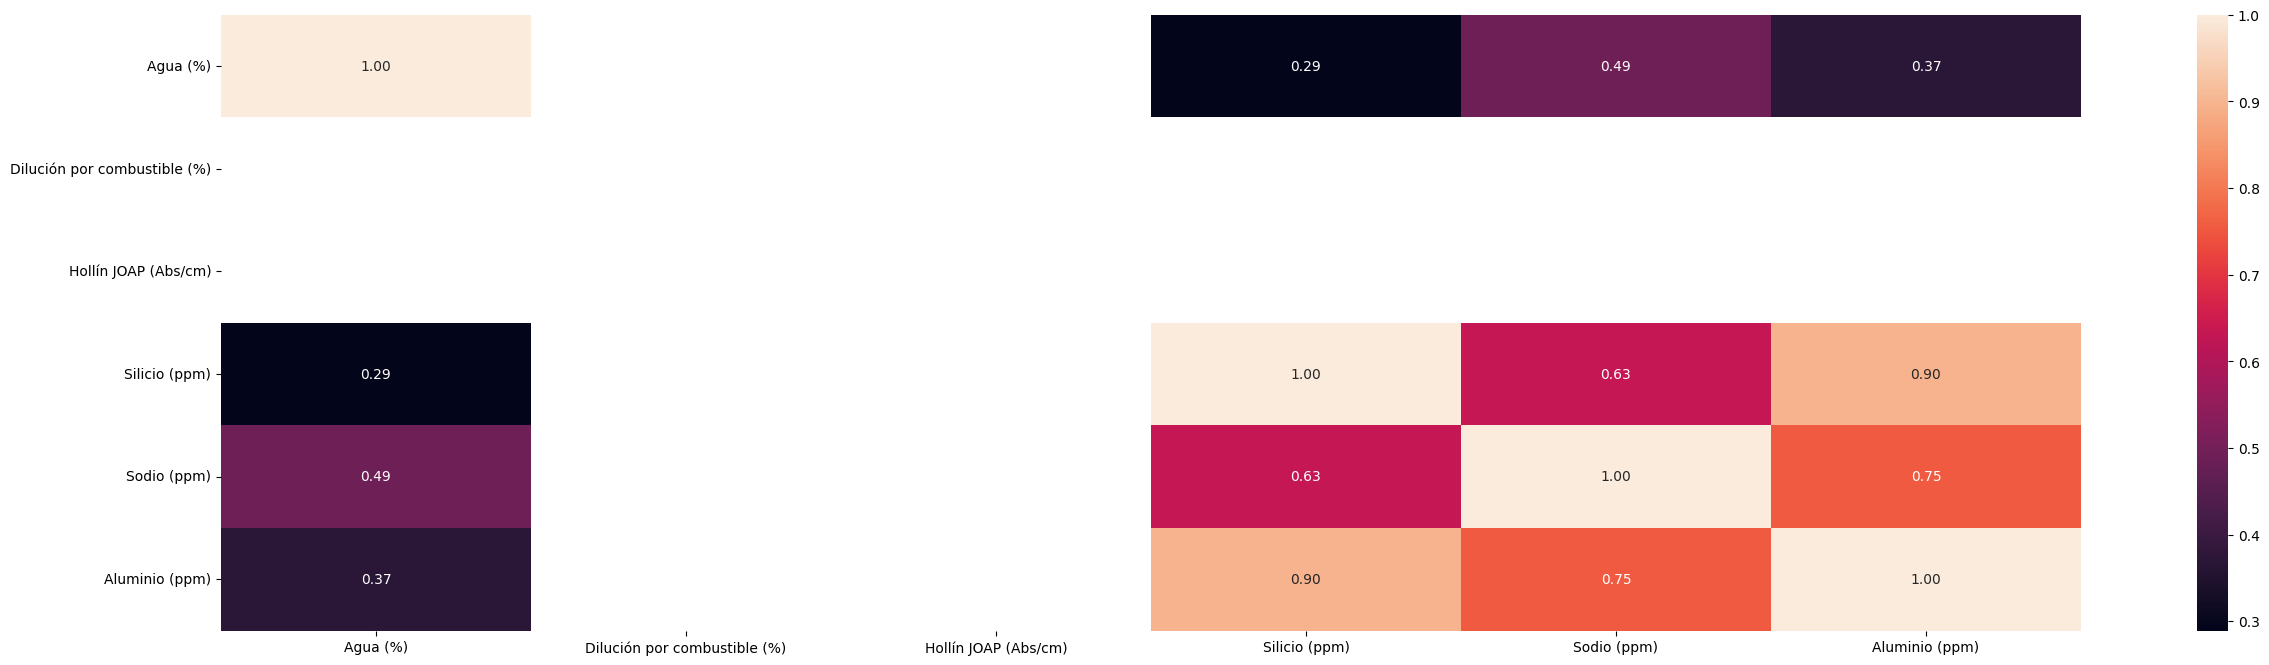

In [10]:
corr = Contaminacion.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(30,8))
sns.heatmap(corr, annot=True, fmt=".2f")

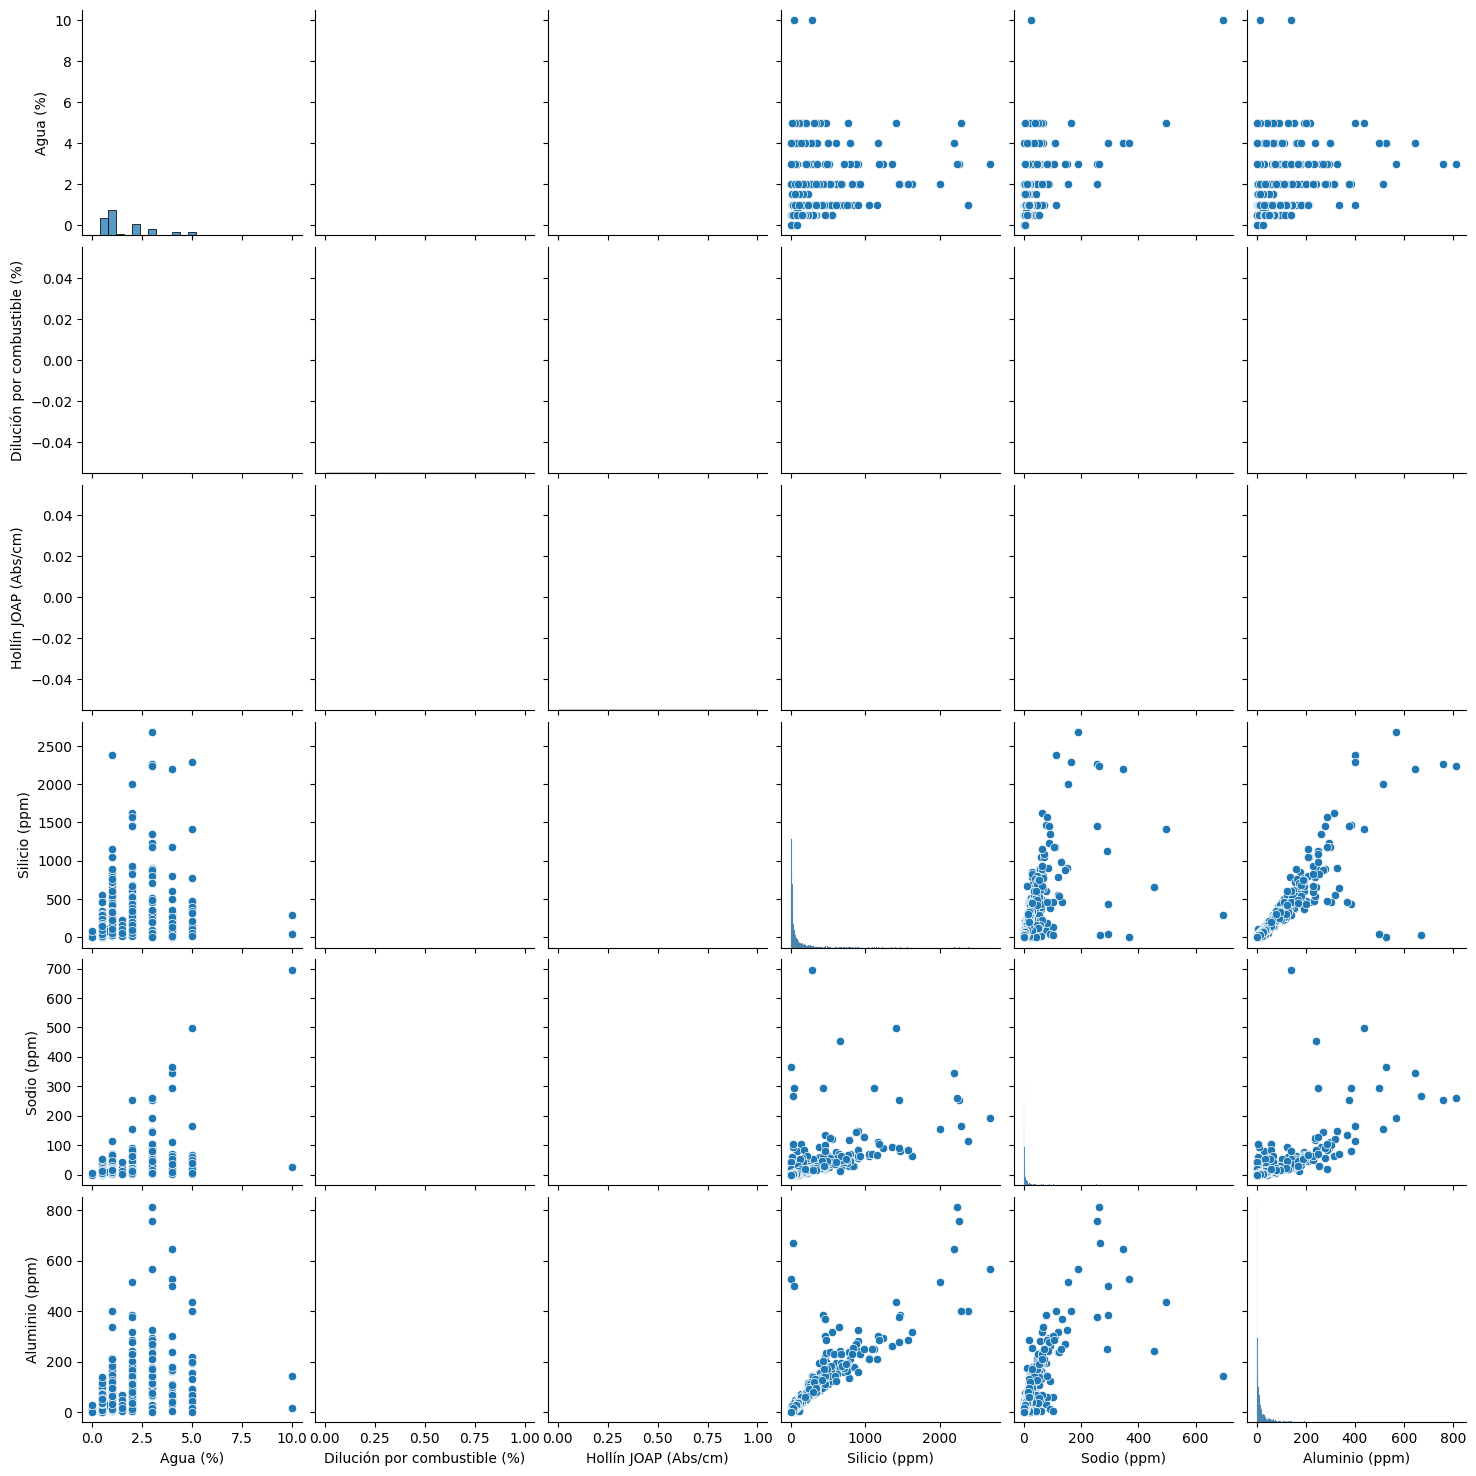

In [11]:
sns.pairplot(Contaminacion)

In [12]:
def PCAR(X):
	from sklearn.decomposition import PCA
	from sklearn.preprocessing import StandardScaler
	scaler = StandardScaler()
	scaler.fit(X)
	XEscaladoTrain = scaler.transform(X)
	p = XEscaladoTrain.shape[1]
	nComponentesElegidas = p  
	pca = PCA(n_components=p).fit(XEscaladoTrain)
	e=pd.DataFrame(pca.explained_variance_ratio_*100)
	loads=pd.DataFrame(pca.components_)
	eigenvalues = pca.explained_variance_
	A = pca.components_
	ZTotalTrain = np.matmul(XEscaladoTrain, A.T)
	ZTrain = ZTotalTrain[:, :nComponentesElegidas]
	varianzaExplicada = pca.explained_variance_
	porcentajeVarianzaExplicada = pca.explained_variance_ratio_
	plt.plot(range(1, p + 1), porcentajeVarianzaExplicada)
	plt.xlabel('Componente')
	plt.title('Varianza de cada componente')
	plt.show()
	plt.plot(range(1, p + 1), np.cumsum(porcentajeVarianzaExplicada))
	plt.xlabel('Cantidad acumulada de componentes principales')
	plt.title('Porcentaje acumulado de varianza explicada')
	plt.show()
	return ZTrain,e,loads,eigenvalues,A

C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Boro (ppm)' 'Dilución por combustible (%)' 'Hollín JOAP (Abs/cm)'
 'Nitración JOAP (Abs/cm)' 'Oxidación JOAP (Abs/cm)'
 'Sulfatación JOAP (Abs/cm)' 'ISO 4406:1999 > 04µ' 'ISO 4406:1999 > 06µ'
 'ISO 4406:1999 > 14µ' 'Bario (ppm)' 'Cadmio (ppm)' 'Estaño (ppm)'
 'Niquel (ppm)' 'Partículas Ferrosas (ppm)' 'Titanio (ppm)'
 'Vanadio (ppm)']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


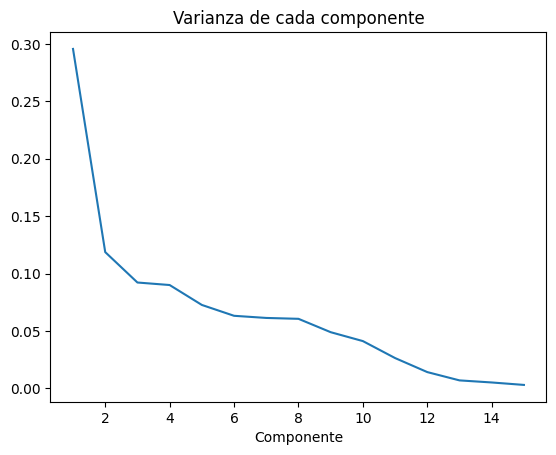

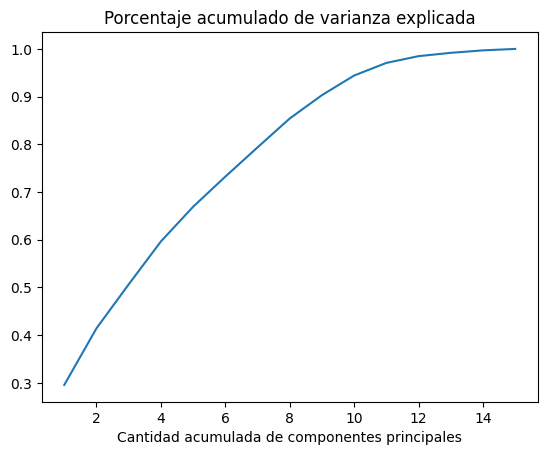

In [15]:
from sklearn.impute import SimpleImputer

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(data.select_dtypes(include=[np.number]))

ZTrain,e,loads,eigenvalues,A = PCAR(X_imputed)

In [19]:
from pca import pca

model_estudiantes = pca(n_components=8,normalize=True, verbose=0)
results_estudiantes = model_estudiantes.fit_transform(X_imputed)

(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': '8 Principal Components explain [85.41%] of the variance'}, xlabel='PC1 (29.5% expl.var)', ylabel='PC2 (11.8% expl.var)'>)

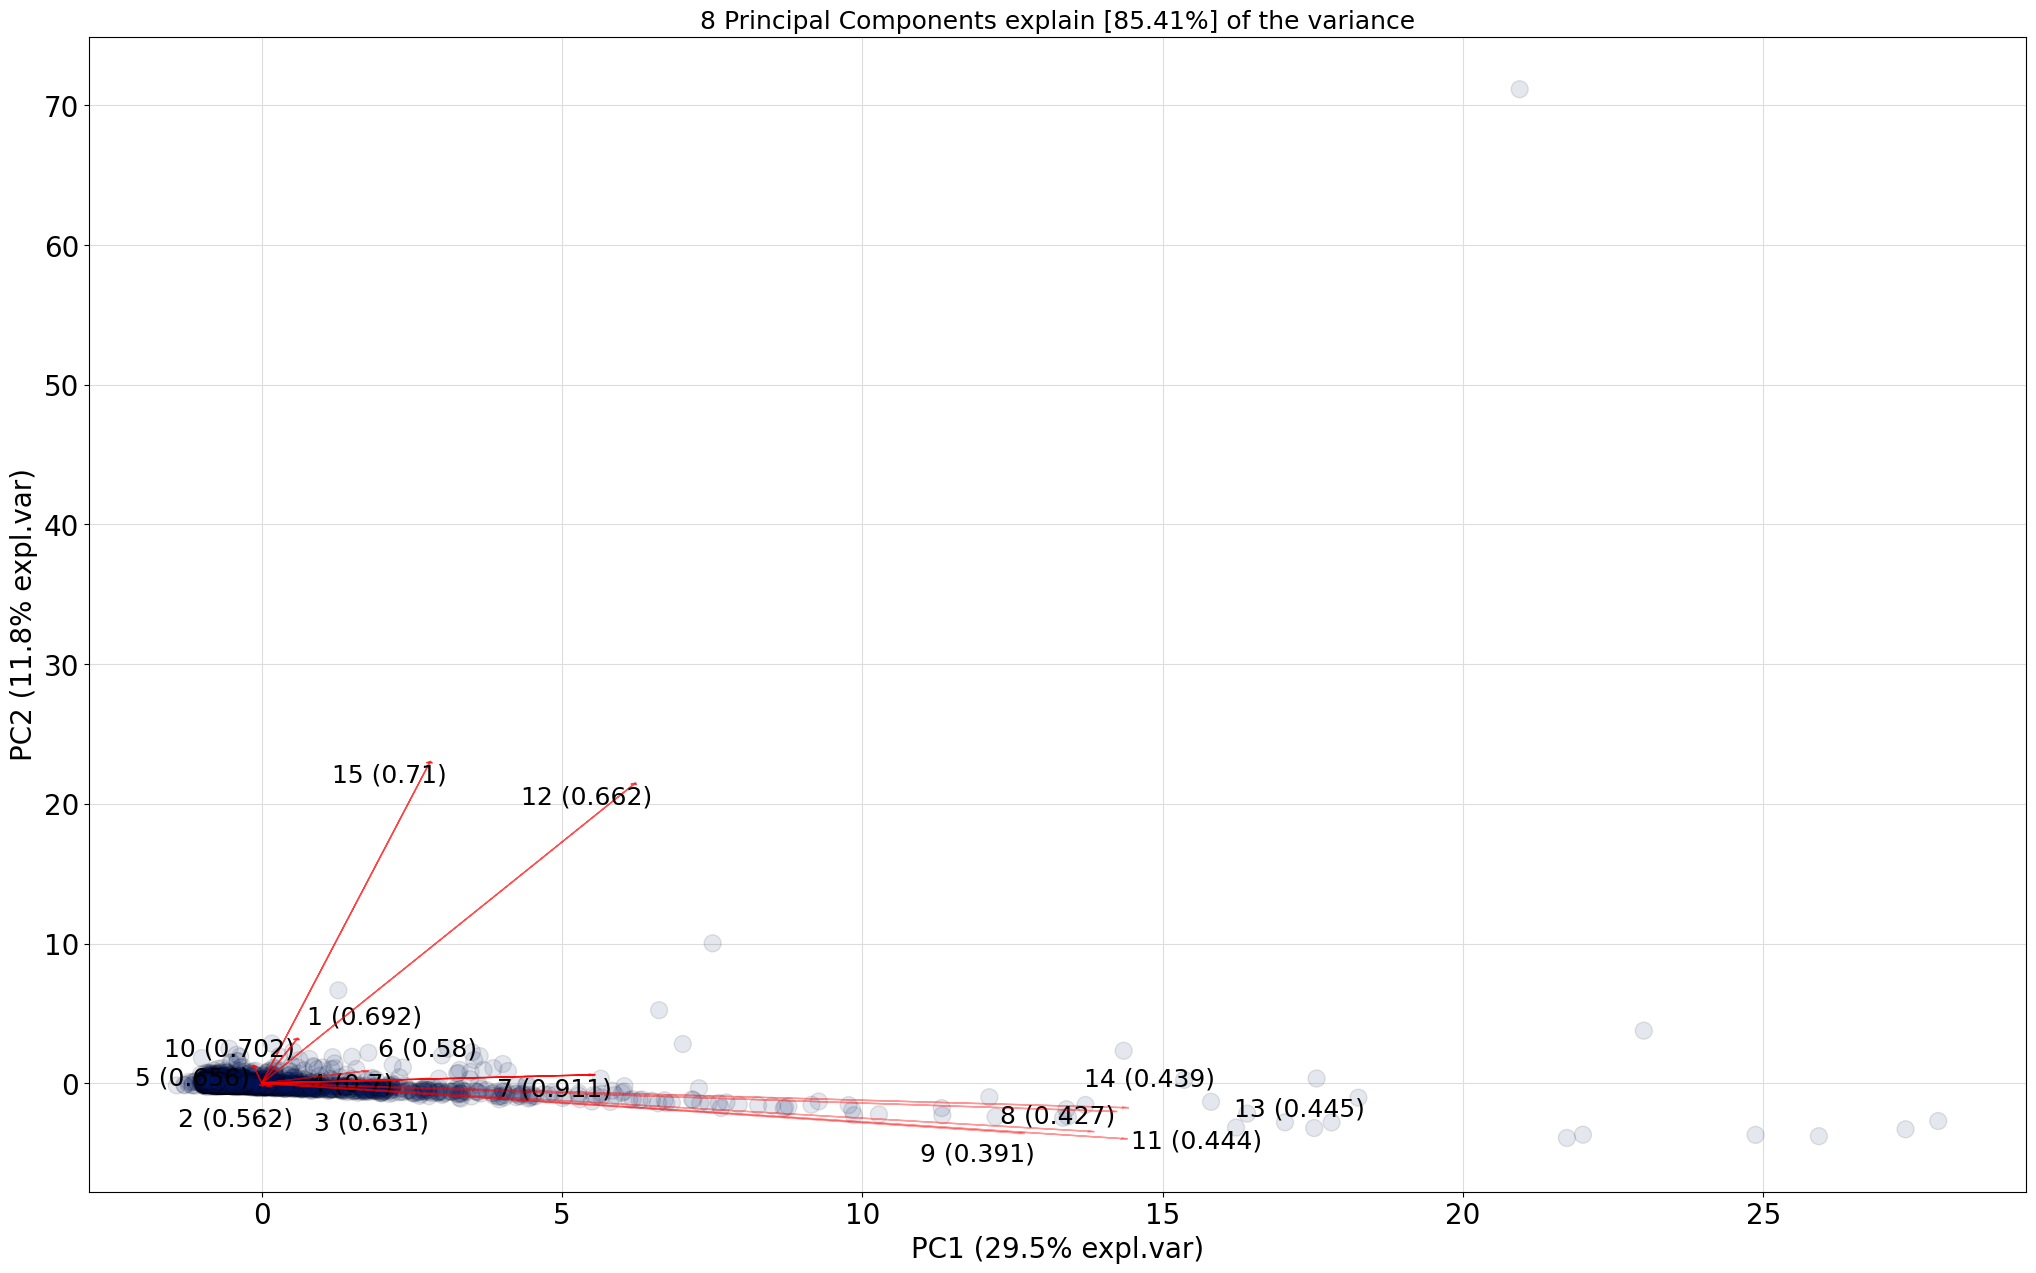

In [20]:
model_estudiantes.biplot(PC=[0, 1], alpha=0.1,legend=False, color_arrow="red", arrowdict={'color_text':"black"})

In [21]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
cols_for_model = list(numeric_cols) + ['Fault Effect']

# Filtrar columnas con al menos 80% de datos no nulos
threshold = 0.8
valid_cols = [col for col in cols_for_model if data[col].notnull().mean() >= threshold]
data_model = data[valid_cols].dropna()

In [22]:


X = data_model.drop(columns=['Fault Effect','Asset ID'])
#X=scale(X)
y = data_model['Fault Effect']

# Verifica que hay suficientes muestras antes de dividir
if len(data_model) > 0:
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
	model = GradientBoostingClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, random_state=42)
	model.fit(X_train, y_train)
else:
	print("No hay suficientes datos para entrenar el modelo. Revisa las columnas seleccionadas y el umbral de valores nulos.")

=== Matriz de Confusión ===
[[ 77   0   0   1   0  44   0   1]
 [  0   0   0   0   0   2   0   0]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   1   0   3   0   0]
 [  1   0   0   0   0   0   0   0]
 [ 43   1   0   1   0 578   0   1]
 [  2   0   0   0   0   7   0   0]
 [  0   0   0   0   0   0   0   0]]

=== Reporte de Clasificación ===
                               precision    recall  f1-score   support

           Dirt Contamination       0.62      0.63      0.62       123
Fluid Condition Deteriorating       0.00      0.00      0.00         2
               Fluid Transfer       0.00      0.00      0.00         2
             High Wear Metals       0.33      0.25      0.29         4
         Incorrect Fluid Type       0.00      0.00      0.00         1
          No Fault Identified       0.91      0.93      0.92       624
  Questionable Sample Results       0.00      0.00      0.00         9
                  Water Entry       0.00      0.00      0.00         0

                

C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} 

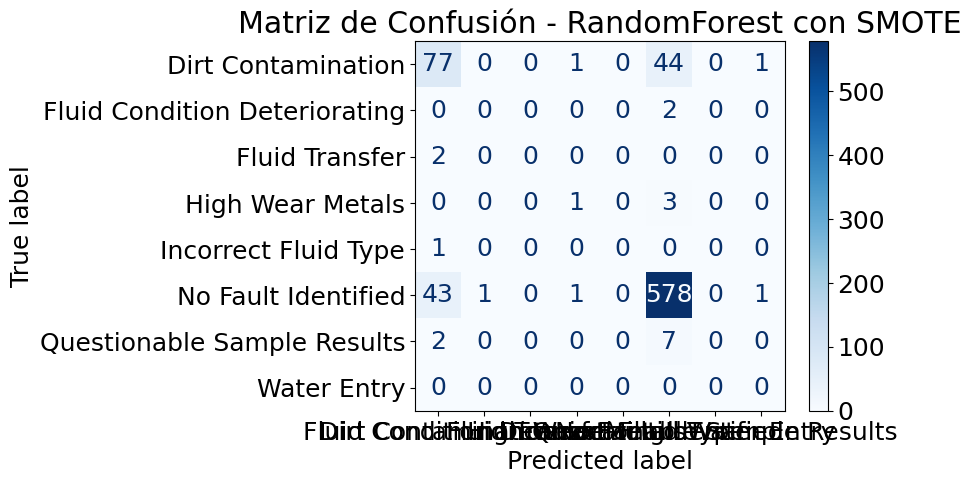

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Predicciones
y_pred = model.predict(X_test)

# Métricas
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualización
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", normalize=None)
plt.title("Matriz de Confusión - RandomForest con SMOTE")
plt.show()

=== Matriz de Confusión ===
[[ 70   0   0   0   0  49   3   1]
 [  0   0   0   0   0   2   0   0]
 [  1   0   0   0   0   1   0   0]
 [  0   0   0   1   0   3   0   0]
 [  1   0   0   0   0   0   0   0]
 [ 41   1   2   0   0 575   4   1]
 [  2   0   0   0   0   7   0   0]
 [  0   0   0   0   0   0   0   0]]

=== Reporte de Clasificación ===
                               precision    recall  f1-score   support

           Dirt Contamination       0.61      0.57      0.59       123
Fluid Condition Deteriorating       0.00      0.00      0.00         2
               Fluid Transfer       0.00      0.00      0.00         2
             High Wear Metals       1.00      0.25      0.40         4
         Incorrect Fluid Type       0.00      0.00      0.00         1
          No Fault Identified       0.90      0.92      0.91       624
  Questionable Sample Results       0.00      0.00      0.00         9
                  Water Entry       0.00      0.00      0.00         0

                

C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} 

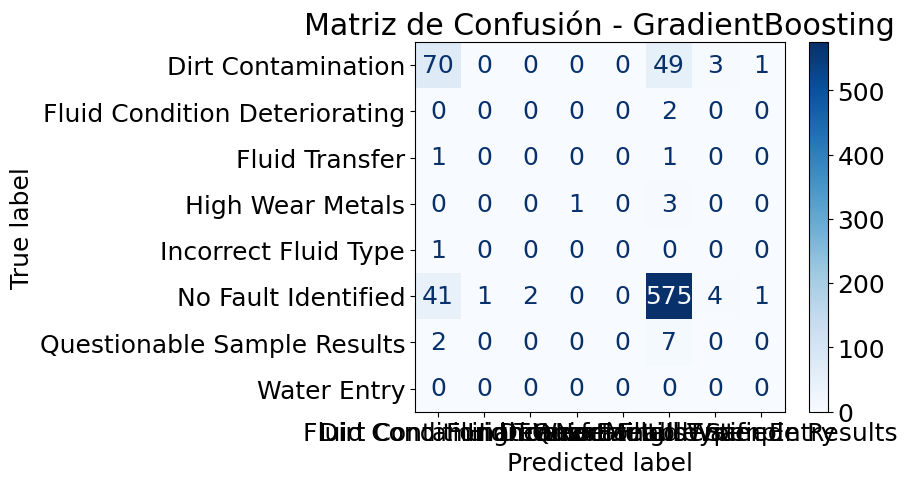

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Balanceo con SMOTE
smote = SMOTE(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)




# Entrenamiento del modelo
model = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualización de la matriz de confusión
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", normalize=None)
plt.title("Matriz de Confusión - GradientBoosting")
plt.show()

=== Matriz de Confusión ===
[[ 56   0   0   0   0  29   0]
 [  0   0   0   0   0   2   0]
 [  2   0   0   0   0   0   0]
 [  0   0   0   1   0   3   0]
 [  0   0   0   0   0   1   0]
 [ 30   0   0   0   0 380   0]
 [  1   0   0   0   0   5   0]]

=== Reporte de Clasificación ===
                               precision    recall  f1-score   support

           Dirt Contamination       0.63      0.66      0.64        85
Fluid Condition Deteriorating       0.00      0.00      0.00         2
               Fluid Transfer       0.00      0.00      0.00         2
             High Wear Metals       1.00      0.25      0.40         4
         Incorrect Fluid Type       0.00      0.00      0.00         1
          No Fault Identified       0.90      0.93      0.92       410
  Questionable Sample Results       0.00      0.00      0.00         6

                     accuracy                           0.86       510
                    macro avg       0.36      0.26      0.28       510
        

C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

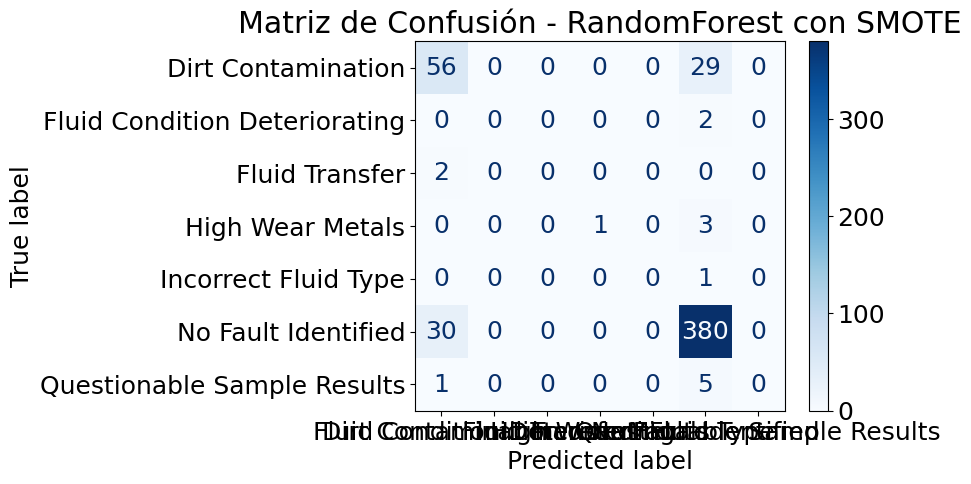

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # usar el de imblearn

# Suponiendo que tu dataset está en un DataFrame
# X = dataset.drop("target", axis=1)
# y = dataset["target"]

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Filtrar clases con menos de 2 muestras en el set de entrenamiento




# Pipeline con SMOTE + RandomForest
model = Pipeline(steps=[
     # aquí se hace el oversampling
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42
    ))
])

# Entrenar modelo (SMOTE se aplica dentro del pipeline)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

# Visualización
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", normalize=None)
plt.title("Matriz de Confusión - RandomForest con SMOTE")
plt.show()

In [42]:
#se genera cross validation para medir el desempeño del modelo
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
# Definir los hiperparámetros a ajustar
param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["auto", "sqrt", "log2"]
}
# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=100,
    cv=skf,
    random_state=42,
    n_jobs=-1
)

# Ajustar RandomizedSearchCV al conjunto de entrenamiento
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("=== Mejores Hiperparámetros ===")
print(random_search.best_params_)
print("\n=== Mejor Accuracy en CV ===")
print(random_search.best_score_)



C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
200 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
166 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dmartin8\AppData\Roaming\Pytho

=== Mejores Hiperparámetros ===
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 20}

=== Mejor Accuracy en CV ===
0.8744459700342053


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": np.arange(100, 600, 100),
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,         # número de combinaciones aleatorias
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("=== Mejores Hiperparámetros ===")
print(random_search.best_params_)
print("\n=== Mejor Accuracy en CV ===")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


=== Mejores Hiperparámetros ===
{'n_estimators': np.int64(200), 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}

=== Mejor Accuracy en CV ===
0.8719865587512647


In [56]:
# se entrena un modelo de regresión logística con SMOTE y preprocesamiento de datos.
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

modelv2=LogisticRegression()

x_pca = ZTrain[:, :10]
x_pca_filtered = x_pca[data_model.index]

X_train_,X_test_,y_train_,y_test_=train_test_split(x_pca_filtered, y, test_size=0.2, random_state=42)

modelv2.fit(X_train_, y_train_)
y_pred_modelv2 = modelv2.predict(X_test_)

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred_modelv2))


=== Reporte de Clasificación ===
                               precision    recall  f1-score   support

           Dirt Contamination       0.60      0.35      0.44        85
Fluid Condition Deteriorating       0.00      0.00      0.00         2
               Fluid Transfer       0.00      0.00      0.00         2
             High Wear Metals       0.00      0.00      0.00         4
         Incorrect Fluid Type       0.00      0.00      0.00         1
          No Fault Identified       0.85      0.96      0.90       410
  Questionable Sample Results       0.00      0.00      0.00         6

                     accuracy                           0.83       510
                    macro avg       0.21      0.19      0.19       510
                 weighted avg       0.79      0.83      0.80       510



C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dmartin8\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

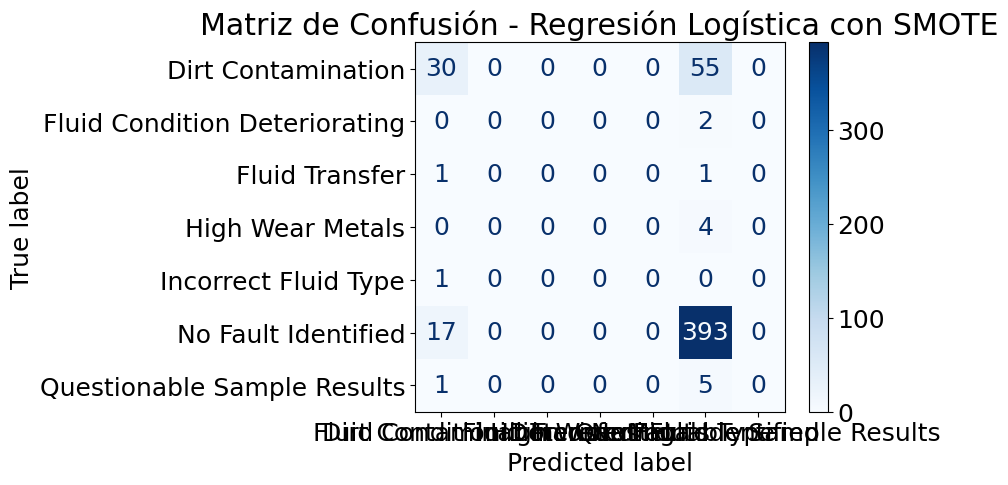

In [57]:
disp = ConfusionMatrixDisplay.from_estimator(modelv2, X_test_, y_test_, cmap="Blues", normalize=None)
plt.title("Matriz de Confusión - Regresión Logística con SMOTE")
plt.show()